In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ============================================================
# NOTEBOOK 03 — PLAYER ARCHETYPE CLUSTERING (Historical)
# ============================================================
# CHANGE FROM BEFORE: We now cluster on HISTORICAL features
# (a player's average across prior games), not single-match
# in-game stats. So archetypes describe a player's general
# playstyle — which is knowable pre-game and can later be
# used as a model feature in notebook 04.
# ============================================================
df = pd.read_csv('df_model_historical.csv')
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: (242757, 13)
Columns: ['Win', 'hist_kda_ratio', 'hist_gold_per_min', 'hist_dmg_per_min', 'hist_cs_per_min', 'hist_visionScore', 'hist_objective_participation', 'Lane', 'RankName', 'GameDuration', 'SummonerFk', 'MatchFk', 'match_num']


k=2: inertia=212959
k=3: inertia=162485
k=4: inertia=134708
k=5: inertia=121581
k=6: inertia=112124
k=7: inertia=104977
k=8: inertia=99223
k=9: inertia=94247
k=10: inertia=89672


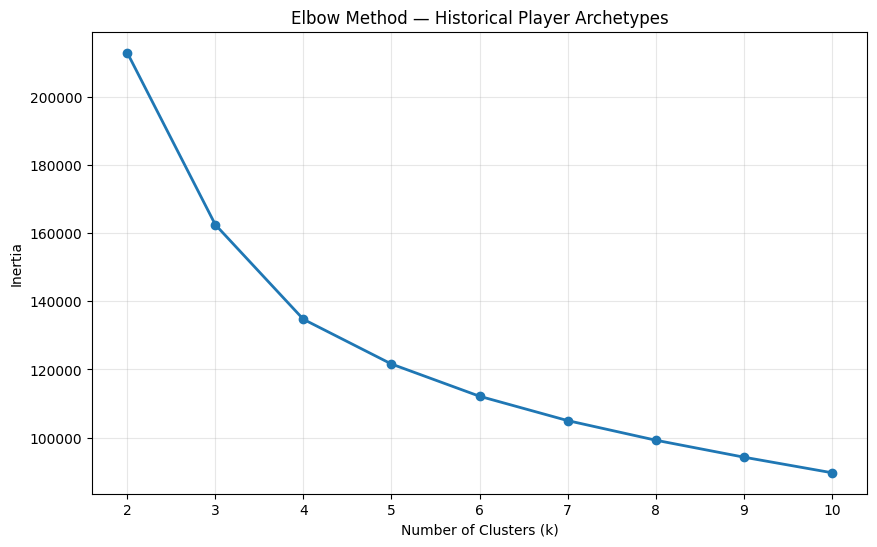

In [ ]:
# ============================================================
# ELBOW METHOD ON HISTORICAL FEATURES
# Find optimal number of player archetypes based on historical
# (pre-game) behavioral averages. We sample for speed.
# ============================================================
X_sample = X_scaled.sample(n=50000, random_state=42)

inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:.0f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Historical Player Archetypes')
plt.grid(True, alpha=0.3)
plt.savefig('elbow_historical.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# FINAL KMEANS WITH k=4 ON HISTORICAL FEATURES
# Fit on the full dataset and attach cluster labels to df
# ============================================================
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

# ============================================================
# CLUSTER PROFILES — mean of historical features per cluster
# This tells us what each archetype's typical playstyle is
# ============================================================
print("\nCluster behavioral profiles (historical means):")
profile = df.groupby('cluster')[cluster_features].mean().round(2)
print(profile)

Cluster sizes:
cluster
0    80270
1    37779
2    38899
3    85809
Name: count, dtype: int64

Cluster behavioral profiles (historical means):
         hist_kda_ratio  hist_gold_per_min  hist_dmg_per_min  hist_cs_per_min  \
cluster                                                                         
0                  4.06             454.98            921.81             6.57   
1                  4.03             310.90            445.54             1.53   
2                  4.57             433.02            706.56             1.57   
3                  2.36             374.89            639.71             5.02   

         hist_visionScore  hist_objective_participation  
cluster                                                  
0                   20.15                          0.22  
1                   60.70                          0.11  
2                   26.50                          1.86  
3                   21.36                          0.21  


In [ ]:
# ============================================================
# NAME ARCHETYPES + CHECK WIN RATES
# Note: win rate here is LESS extreme than the in-game version
# because these are historical profiles, not current-game stats
# — exactly what we want (no circularity)
# ============================================================
archetype_names = {
    0: 'The Carry',
    1: 'The Vision Support',
    2: 'The Playmaker',
    3: 'The Inconsistent'
}
df['archetype'] = df['cluster'].map(archetype_names)

print("Archetype distribution:")
print(df['archetype'].value_counts())

print("\nWin rate by archetype (historical):")
print(df.groupby('archetype')['Win'].mean().round(3).sort_values(ascending=False))

# Save for notebook 04
df.to_csv('df_clustered_historical.csv', index=False)
print("\nSaved df_clustered_historical.csv")

Archetype distribution:
archetype
The Inconsistent      85809
The Carry             80270
The Playmaker         38899
The Vision Support    37779
Name: count, dtype: int64

Win rate by archetype (historical):
archetype
The Carry             0.514
The Vision Support    0.504
The Playmaker         0.501
The Inconsistent      0.491
Name: Win, dtype: float64

Saved df_clustered_historical.csv
